# TinyML - Spiking Neural Networks

**Author:** Thommas Kevin Sales Flores  

**Institution:** Federal University of Rio Grande do Norte

**Email:** thommas.flores.101@ufrn.edu.br

## Environment Setup

The following commands install the required Python packages. They are commented out by default because the environment may already be configured. If you are running this notebook for the first time, uncomment and execute them to install:

## 1. Setup and Imports

Install required packages if not already present.

In [1]:
#!pip install -r requirements.txt

In [2]:
import sys
sys.path.append("33_SNN")
import torch
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from model import SpikingModel
from layers import SpikingLinear, LeakyReadout
from vi import snn_loss
from utils import export_to_json, plot_decision_boundary, plot_regression_uncertainty
from cpp_generator import generate_ino

os.makedirs('json_model', exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

## 1. Regression Example: 1D Sine with a Gap

We train an SNN to predict `y = sin(x)` but only provide training data in the intervals `[-4, -1.5]` and `[1.5, 4]`. The model should exhibit **high uncertainty** in the gap `(-1.5, 1.5)` where no data is available.

In SNNs, uncertainty arises naturally from the **stochastic rate-coded encoding**: each forward pass samples a different spike train from the same input intensity via Bernoulli sampling, yielding a natural estimate of predictive variance — analogous to the weight-sampling mechanism in BNNs.

> **SNN vs BNN:** In a BNN the uncertainty comes from the posterior over weights (sampled at each forward pass). In an SNN it comes from the spike-train randomness — different binary spike sequences are generated from the same firing rate at every forward pass, leading to variable readout potentials.

## ⚠️ Important: Python vs Arduino prediction comparison

To compare Python output with the Arduino Serial output you **must** use `model.predict(x)` instead of `model(x)`:

| Method | Encoding | Deterministic? | Use for |
|---|---|---|---|
| `model(x)` / `forward()` | `rate` — Bernoulli(x) | ❌ stochastic | **Training** |
| `model.predict(x)` | `repeat` — constant injection | ✅ deterministic | **Arduino comparison** |

The C++ `predict()` copies `input[i]` directly to the spike buffer at every time step — this is equivalent to `encoding='repeat'`. Training with `'rate'` is beneficial (acts as a regulariser via spike-train noise), but deployment inference must be deterministic.

```python
# ✅ Correct comparison
py_out = model.predict(x_normalised)   # deterministic → matches Arduino

# ❌ Wrong for comparison (stochastic, changes every call)
py_out = model(x_normalised)           # uses Bernoulli sampling
```

Starting 1D Regression Training (SNN)...
X_train[0]: tensor([-4.])
y_train[0]: tensor([0.9495])
X_test[0] : tensor([-5.])
y_test[0] : tensor([0.9589])
  Epoch   50 | Loss: 0.3118
  Epoch  100 | Loss: 0.2910


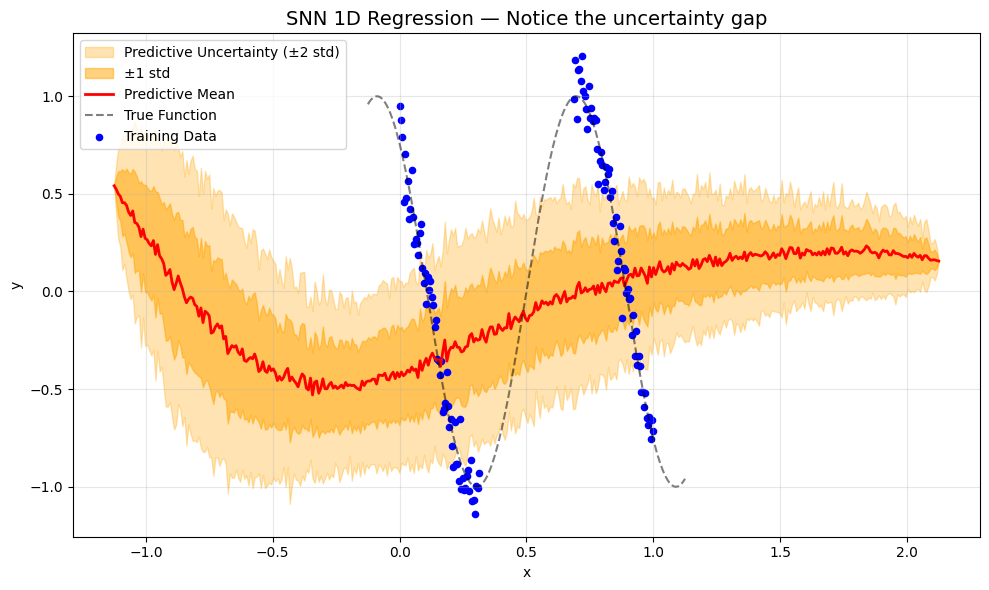

[export_to_json] Model saved to 'json_model/snn_regression_model.json'.
[SNNArduinoGenerator] Files written to 'arduino_code/snn_regression_ino' (board: esp32, steps: 25).
Regression Arduino project generated in 'arduino_code/snn_regression_ino' folder.

  Input → tensor([[0.]])  ← compare with Arduino Serial
  [Python  predict()] → [[0.54147345]]  ← compare with Arduino Serial
  [Python forward()  ] → [[0.54147345]]


In [ ]:
def train_regression_educational():
    print("Starting 1D Regression Training (SNN)...")
    torch.manual_seed(42)

    # ------------------------------------------------------------------ #
    # Data: sine with a deliberate gap so uncertainty is visible          #
    # ------------------------------------------------------------------ #
    x_train_1 = torch.linspace(-4, -1.5, 60)
    x_train_2 = torch.linspace(1.5, 4, 60)
    X_train = torch.cat([x_train_1, x_train_2]).view(-1, 1)
    y_train = torch.sin(X_train) + 0.1 * torch.randn_like(X_train)

    X_test = torch.linspace(-5, 5, 200).view(-1, 1)
    y_test = torch.sin(X_test)

    print("X_train[0]:", X_train[0])
    print("y_train[0]:", y_train[0])
    print("X_test[0] :", X_test[0])
    print("y_test[0] :", y_test[0])

    # ------------------------------------------------------------------ #
    # Normalise inputs to [0, 1] — required for rate-coded Bernoulli      #
    # encoding, which expects probabilities in that range.                #
    # ------------------------------------------------------------------ #
    x_min, x_max = X_train.min(), X_train.max()
    X_train_enc = (X_train - x_min) / (x_max - x_min + 1e-8)
    X_test_enc  = (X_test  - x_min) / (x_max - x_min + 1e-8)

    # ------------------------------------------------------------------ #
    # SNN architecture                                                    #
    # SpikingLinear → LIF neurons → spikes propagate through time         #
    # LeakyReadout  → non-spiking integrator used as the output layer     #
    # ------------------------------------------------------------------ #
    model = SpikingModel([
        SpikingLinear(1, 64, beta=0.9, threshold=1.0),
        SpikingLinear(64, 64, beta=0.9, threshold=1.0),
        LeakyReadout(64, 1, beta=0.9)
    ], num_steps=25, encoding='rate')

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X_train_enc)          # (batch, 1) — time-averaged membrane
        loss = snn_loss(output, y_train.squeeze(-1), likelihood='regression')
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:4d} | Loss: {loss.item():.4f}")

    plot_regression_uncertainty(
        model, X_train_enc, y_train, X_test_enc, y_test,
        title="SNN 1D Regression — Notice the uncertainty gap",
        n_samples=100
    )

    # Export model and generate Arduino/ESP32 code
    export_to_json(model, 'json_model/snn_regression_model.json')
    generate_ino(
        'json_model/snn_regression_model.json',
        'arduino_code/snn_regression_ino',
        board='esp32',
        task='regression'
    )
    print("Regression Arduino project generated in 'arduino_code/snn_regression_ino' folder.\n")

    # ------------------------------------------------------------------ #
    # Deterministic comparison: Python predict() must match C++ output    #
    # Use model.predict() — NOT model(x) — when comparing to Arduino.    #
    # model(x) uses rate encoding (stochastic Bernoulli); predict() uses  #
    # repeat encoding (constant injection), which is what the C++ does.  #
    # ------------------------------------------------------------------ #
    sample = X_train_enc[:1]   # first sample, already normalised

    model.eval()

    py_out = model.predict(sample)

    with torch.no_grad():
        forward_out = model(sample)

    print(f"  Input → {sample}  ← use in arduino code")
    print(f"  [Python  predict()] → {py_out.numpy()}  ← compare with Arduino Serial")
    print(f"  [Python forward()  ] → {forward_out.numpy()}")
    return model


model_reg = train_regression_educational()

## 2. Binary Classification: Moon Dataset

We train an SNN on the classic two-moon dataset. The stochastic spike-train encoding provides natural uncertainty estimates — the model is more confident near the training data and less confident near the decision boundary.

> **Key difference from BNN:** A BNN draws different weights at each forward pass, producing different logits. An SNN draws different binary spike sequences from the same firing rates — both mechanisms yield a distribution over outputs that we can use to estimate uncertainty.

Starting Binary Classification Training (SNN)...
X_train[0]: [ 1.5184023  -0.55922781]
y_train[0]: 1
X_test[0] : [ 0.50799168 -0.34745972]
y_test[0] : 1


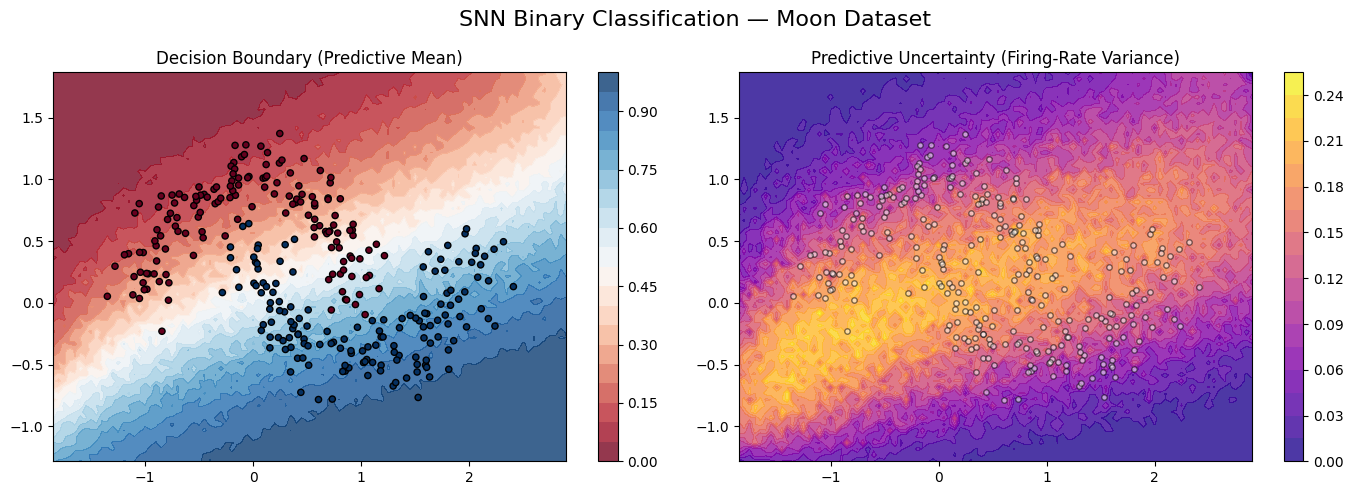

[export_to_json] Model saved to 'json_model/snn_binary_model.json'.
[SNNArduinoGenerator] Files written to 'arduino_code/snn_binary_ino' (board: esp32, steps: 25).
Binary Arduino project generated in 'arduino_code/snn_binary_ino' folder.

  Input → tensor([[0.7630, 0.1066]])  ← use in arduino code
  [Python  predict()] → [[3.2131665]]  ← compare with Arduino Serial
  [Python forward()  ] → [[4.6697903]]


In [ ]:
def train_binary():
    print("Starting Binary Classification Training (SNN)...")
    X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)

    print("X_train[0]:", X_train[0])
    print("y_train[0]:", y_train[0])
    print("X_test[0] :", X_test[0])
    print("y_test[0] :", y_test[0])

    # ------------------------------------------------------------------ #
    # Normalise to [0, 1] for rate-coded Bernoulli encoding               #
    # ------------------------------------------------------------------ #
    x_min = X_train_t.min(dim=0).values
    x_max = X_train_t.max(dim=0).values
    X_train_enc = (X_train_t - x_min) / (x_max - x_min + 1e-8)

    # ------------------------------------------------------------------ #
    # SNN architecture for binary classification                          #
    # Output: 1 logit from LeakyReadout → BCEWithLogits                  #
    # ------------------------------------------------------------------ #
    model = SpikingModel([
        SpikingLinear(2, 20, beta=0.9, threshold=1.0),
        SpikingLinear(20, 20, beta=0.9, threshold=1.0),
        LeakyReadout(20, 1, beta=0.9)
    ], num_steps=25, encoding='rate')

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X_train_enc)          # (batch, 1)
        loss = snn_loss(output, y_train_t, likelihood='binary')
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch+1:4d} | Loss: {loss.item():.4f}")

    plot_decision_boundary(
        model, X, y,
        title="SNN Binary Classification — Moon Dataset",
        task='binary',
        n_samples=50
    )

    # Export model and generate Arduino/ESP32 code
    export_to_json(model, 'json_model/snn_binary_model.json')
    generate_ino(
        'json_model/snn_binary_model.json',
        'arduino_code/snn_binary_ino',
        board='esp32',
        task='binary'
    )
    print("Binary Arduino project generated in 'arduino_code/snn_binary_ino' folder.\n")

    # ------------------------------------------------------------------ #
    # Deterministic comparison: Python predict() must match C++ output    #
    # Use model.predict() — NOT model(x) — when comparing to Arduino.    #
    # model(x) uses rate encoding (stochastic Bernoulli); predict() uses  #
    # repeat encoding (constant injection), which is what the C++ does.  #
    # ------------------------------------------------------------------ #
    sample = X_train_enc[:1]   # first sample, already normalised

    model.eval()

    py_out = model.predict(sample)

    with torch.no_grad():
        forward_out = model(sample)

    print(f"  Input → {sample}  ← use in arduino code")
    print(f"  [Python  predict()] → {py_out.numpy()}  ← compare with Arduino Serial")
    print(f"  [Python forward()  ] → {forward_out.numpy()}")
    return model


model_bin = train_binary()

## 3. Multiclass Classification: Blobs Dataset

For more than two classes, the LeakyReadout layer outputs one logit per class and we use cross-entropy loss. The SNN processes each input as a sequence of spike trains over `num_steps` time steps and returns the time-averaged membrane potential as the final logit vector.

> **Temporal dynamics:** Unlike a standard feedforward network, an SNN accumulates evidence over time. The `num_steps=25` setting means each input is presented for 25 discrete time steps, with the network integrating information across that window before producing a class decision.

Starting Multiclass Classification Training (SNN)...
X_train[0]: [-2.62485019  9.52601409]
y_train[0]: 0
X_test[0] : [3.0840096  1.68766167]
y_test[0] : 1
  Epoch  200 | Loss: 0.0480
  Epoch  400 | Loss: 0.0296
  Epoch  600 | Loss: 0.0384
  Epoch  800 | Loss: 0.0638
  Epoch 1000 | Loss: 0.0560


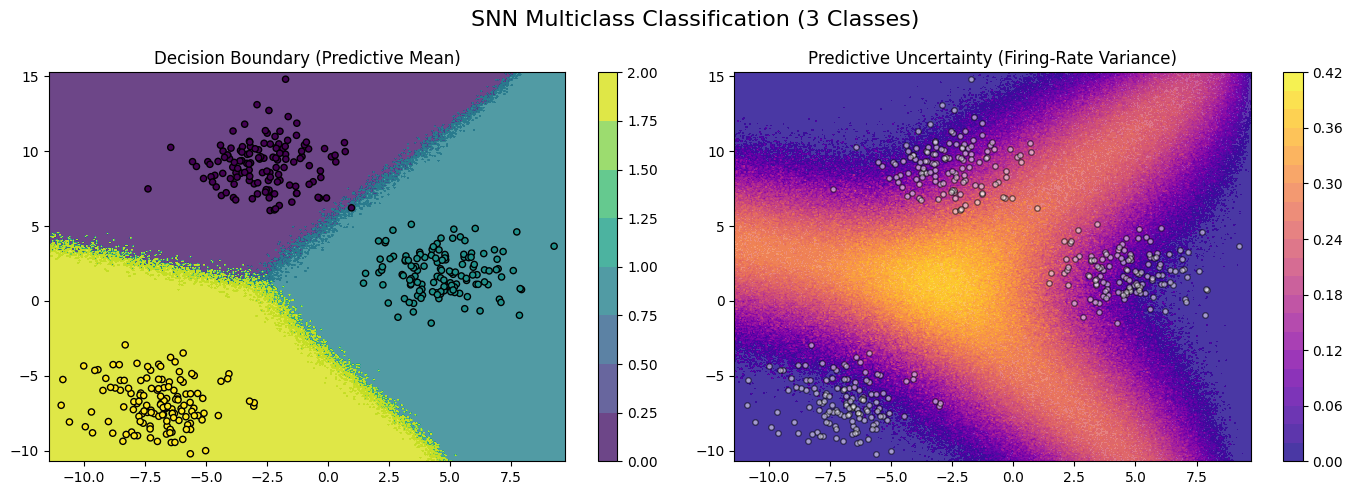

[export_to_json] Model saved to 'json_model/snn_multiclass_model.json'.
[SNNArduinoGenerator] Files written to 'arduino_code/snn_multiclass_ino' (board: esp32, steps: 25).
Multiclass Arduino project generated in 'arduino_code/snn_multiclass_ino' folder.

  Input → tensor([[0.4112, 0.8610]])  ← use in arduino code
  [Python  predict()] → [[ 11.206675   -1.3554206 -13.168942 ]]  ← compare with Arduino Serial
  [Python forward()  ] → [[  3.8632822   2.848656  -10.680901 ]]


In [11]:
def train_multiclass():
    print("Starting Multiclass Classification Training (SNN)...")
    X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)

    print("X_train[0]:", X_train[0])
    print("y_train[0]:", y_train[0])
    print("X_test[0] :", X_test[0])
    print("y_test[0] :", y_test[0])

    # ------------------------------------------------------------------ #
    # Normalise to [0, 1] for rate-coded encoding                         #
    # ------------------------------------------------------------------ #
    x_min = X_train_t.min(dim=0).values
    x_max = X_train_t.max(dim=0).values
    X_train_enc = (X_train_t - x_min) / (x_max - x_min + 1e-8)

    # ------------------------------------------------------------------ #
    # SNN architecture for 3-class classification                         #
    # Output: 3 logits from LeakyReadout → CrossEntropy                   #
    # ------------------------------------------------------------------ #
    model = SpikingModel([
        SpikingLinear(2, 30, beta=0.9, threshold=1.0),
        LeakyReadout(30, 3, beta=0.9)
    ], num_steps=25, encoding='rate')

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(1000):
        optimizer.zero_grad()
        output = model(X_train_enc)          # (batch, 3)
        loss = snn_loss(output, y_train_t, likelihood='classification')
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch+1:4d} | Loss: {loss.item():.4f}")

    plot_decision_boundary(
        model, X, y,
        title="SNN Multiclass Classification (3 Classes)",
        task='multiclass',
        n_samples=50
    )

    # Export model and generate Arduino/ESP32 code
    export_to_json(model, 'json_model/snn_multiclass_model.json')
    generate_ino(
        'json_model/snn_multiclass_model.json',
        'arduino_code/snn_multiclass_ino',
        board='esp32',
        task='multiclass'
    )
    print("Multiclass Arduino project generated in 'arduino_code/snn_multiclass_ino' folder.\n")

    # ------------------------------------------------------------------ #
    # Deterministic comparison: Python predict() must match C++ output    #
    # Use model.predict() — NOT model(x) — when comparing to Arduino.    #
    # model(x) uses rate encoding (stochastic Bernoulli); predict() uses  #
    # repeat encoding (constant injection), which is what the C++ does.  #
    # ------------------------------------------------------------------ #
    sample = X_train_enc[:1]   # first sample, already normalised

    model.eval()

    py_out = model.predict(sample)

    with torch.no_grad():
        forward_out = model(sample)

    print(f"  Input → {sample}  ← use in arduino code")
    print(f"  [Python  predict()] → {py_out.numpy()}  ← compare with Arduino Serial")
    print(f"  [Python forward()  ] → {forward_out.numpy()}")
    return model


model_multi = train_multiclass()